In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier



In [63]:
df = pd.read_csv('data\weather-classification.csv')

<>:1: SyntaxWarning: invalid escape sequence '\w'
<>:1: SyntaxWarning: invalid escape sequence '\w'
C:\Users\ITG\AppData\Local\Temp\ipykernel_6168\4093945721.py:1: SyntaxWarning: invalid escape sequence '\w'
  df = pd.read_csv('data\weather-classification.csv')


In [114]:
df.head(10)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14,NaN,9.5,82,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39,NaN,8.5,71,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30,NaN,7.0,16,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38,83.0,1.5,82,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27,74.0,17.0,66,overcast,990.67,1,Winter,2.5,mountain,Rainy
5,32,55.0,3.5,26,overcast,1010.03,2,Summer,5.0,inland,Cloudy
6,-2,97.0,8.0,86,overcast,990.87,1,Winter,4.0,inland,Snowy
7,3,85.0,6.0,96,partly cloudy,984.46,1,Winter,3.5,inland,Snowy
8,3,83.0,6.0,66,overcast,999.44,0,Winter,1.0,mountain,Snowy
9,28,74.0,8.5,107,clear,1012.13,8,Winter,7.5,coastal,Sunny


In [115]:
# no null value

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  int64  
 1   Humidity              13189 non-null  float64
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  int64  
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(4), int64(3), object(4)
memory usage: 1.1+ MB


In [64]:
df.dtypes

Temperature               int64
Humidity                float64
Wind Speed              float64
Precipitation (%)         int64
Cloud Cover              object
Atmospheric Pressure    float64
UV Index                  int64
Season                   object
Visibility (km)         float64
Location                 object
Weather Type             object
dtype: object

In [66]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Temperature,13200.0,NaN,NaN,NaN,19.127576,17.386327,-25.0,4.0,21.0,31.0,109.0
Humidity,13189.0,NaN,NaN,NaN,68.709758,20.198933,20.0,57.0,70.0,84.0,109.0
Wind Speed,13200.0,NaN,NaN,NaN,9.832197,6.908704,0.0,5.0,9.0,13.5,48.5
Precipitation (%),13200.0,NaN,NaN,NaN,53.644394,31.946541,0.0,19.0,58.0,82.0,109.0
Cloud Cover,13200,4,overcast,6090,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Atmospheric Pressure,13200.0,NaN,NaN,NaN,1005.827896,37.199589,800.12,994.8,1007.65,1016.7725,1199.21
UV Index,13200.0,NaN,NaN,NaN,4.005758,3.8566,0.0,1.0,3.0,7.0,14.0
Season,13200,4,Winter,5610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Visibility (km),13200.0,NaN,NaN,NaN,5.462917,3.371499,0.0,3.0,5.0,7.5,20.0
Location,13200,3,inland,4816,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Temperature', ylabel='Count'>

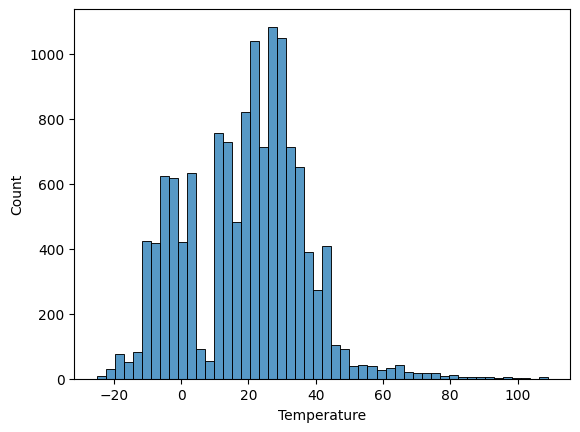

In [67]:
sns.histplot(df.Temperature, bins=50)

In [68]:
df['Weather Type'].unique()

array(['Rainy', 'Cloudy', 'Sunny', 'Snowy'], dtype=object)

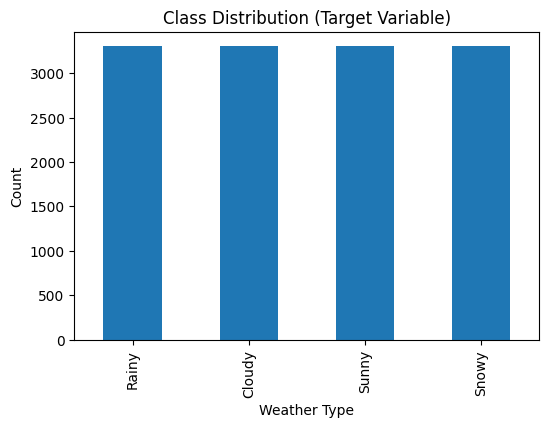

In [71]:
# Class distribution of weather types.
# The graph shows that the data of the weather type  is balanced

plt.figure(figsize=(6,4))
df['Weather Type'].value_counts().plot(kind='bar')
plt.xlabel("Weather Type")
plt.ylabel("Count")
plt.title("Class Distribution (Target Variable)")
plt.show()

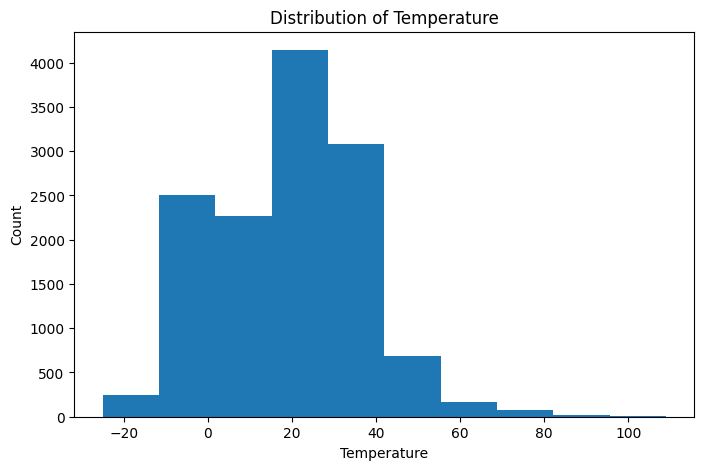

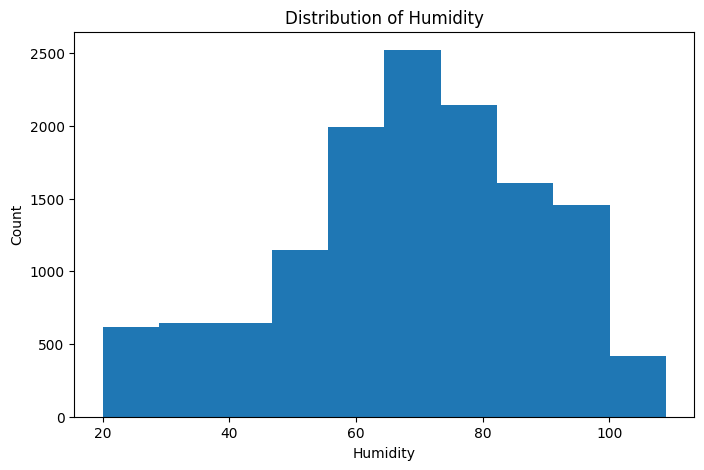

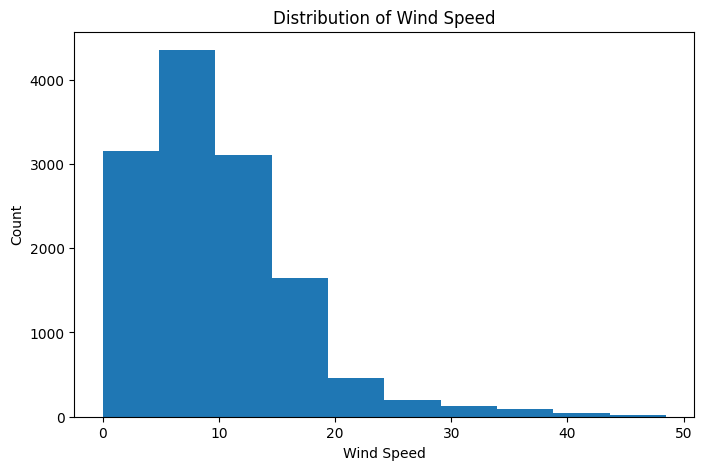

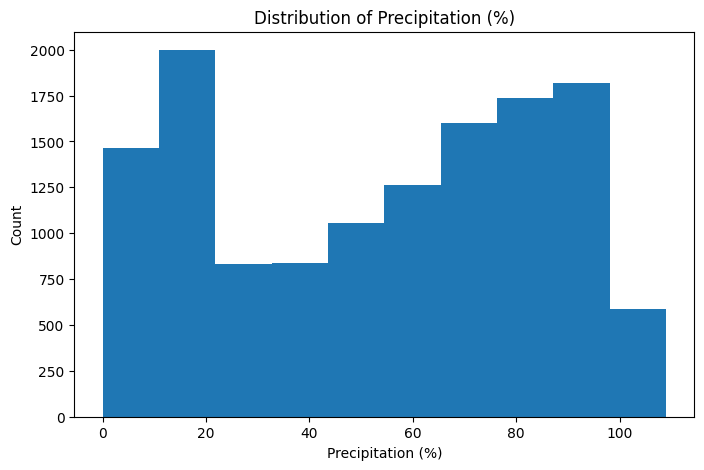

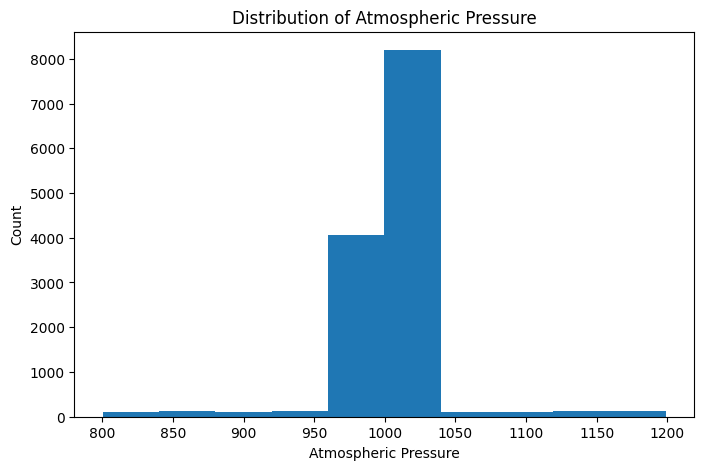

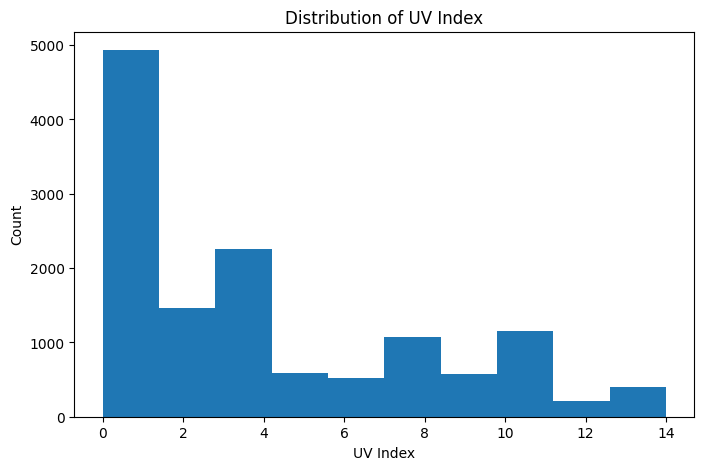

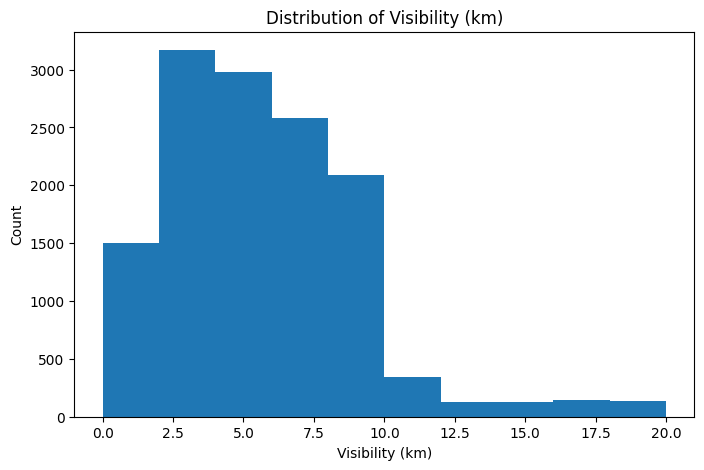

In [72]:
# 3. DISTRIBUTION OF NUMERIC COLUMNS
# ============================

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(8,5))
    plt.hist(df[col])
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.show()

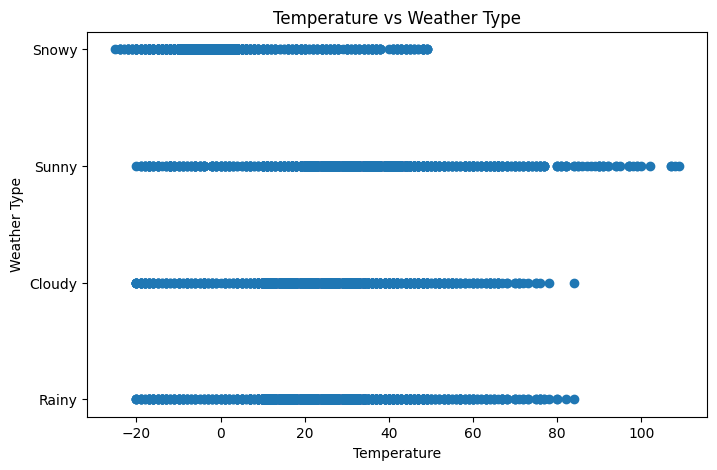

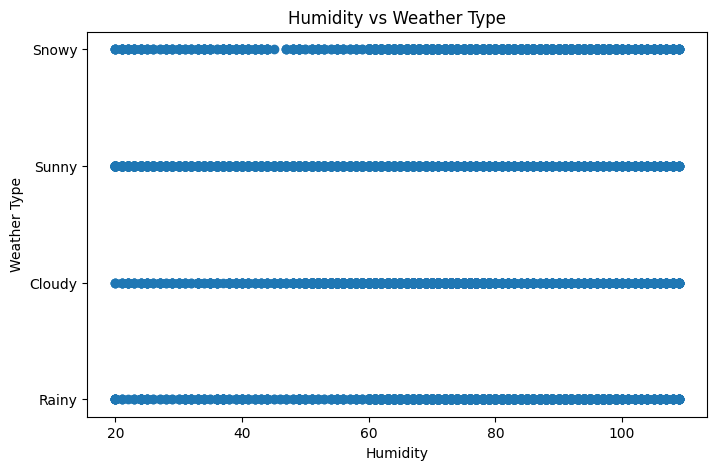

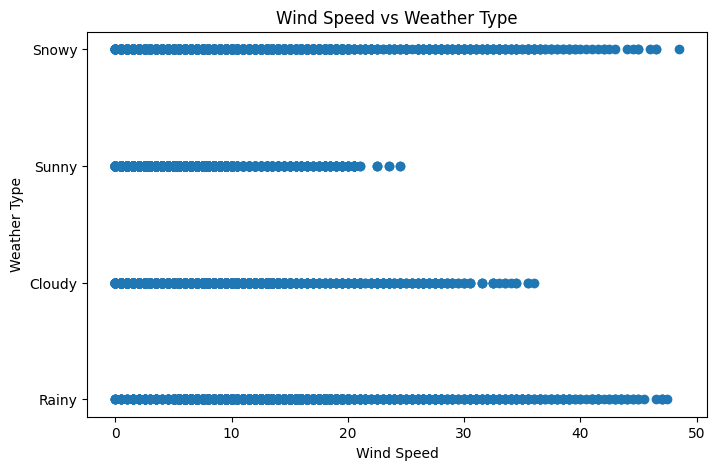

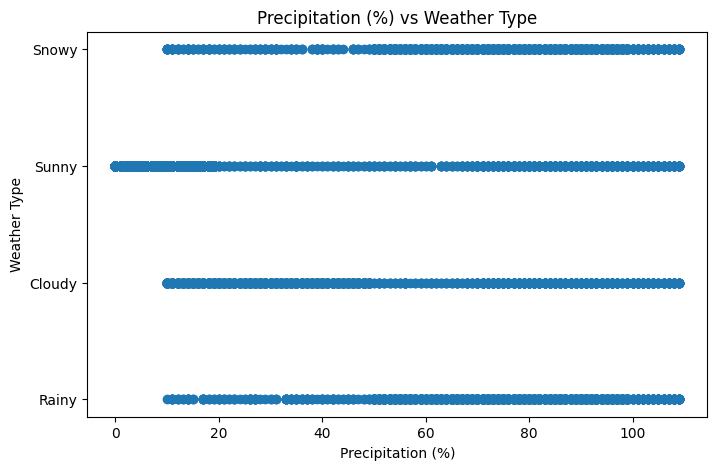

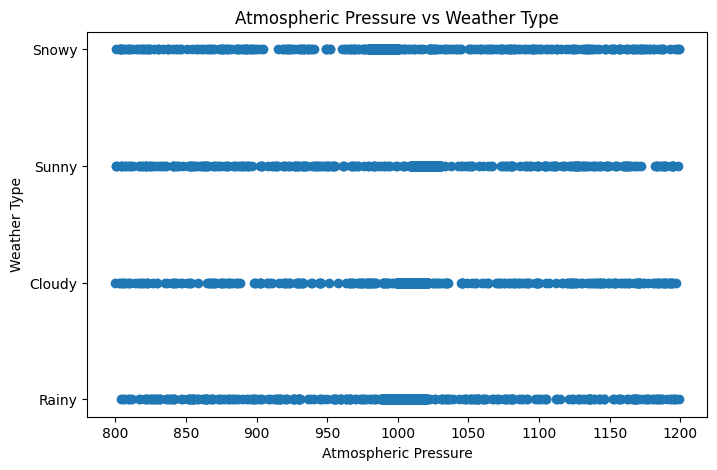

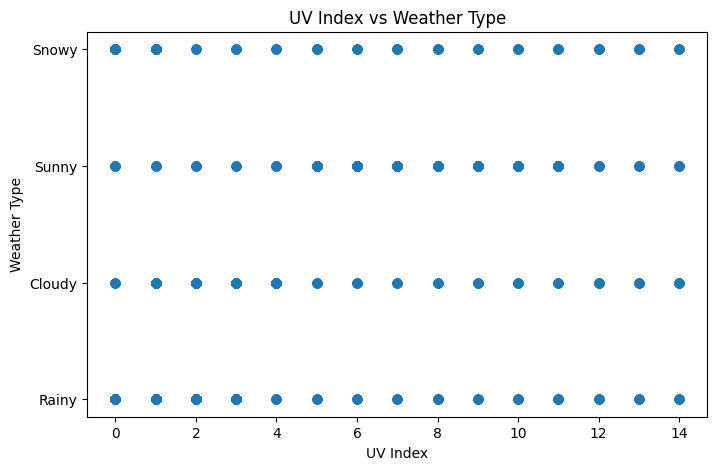

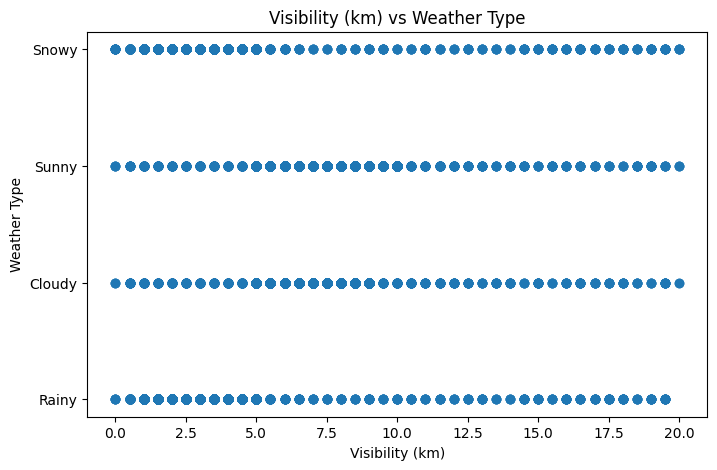

In [73]:
# 4. SCATTERPLOTS OF FEATURES vs TARGET
# ============================

for col in numeric_cols:
    plt.figure(figsize=(8,5))
    plt.scatter(df[col], df['Weather Type'])
    plt.xlabel(col)
    plt.ylabel("Weather Type")
    plt.title(f"{col} vs Weather Type")
    plt.show()

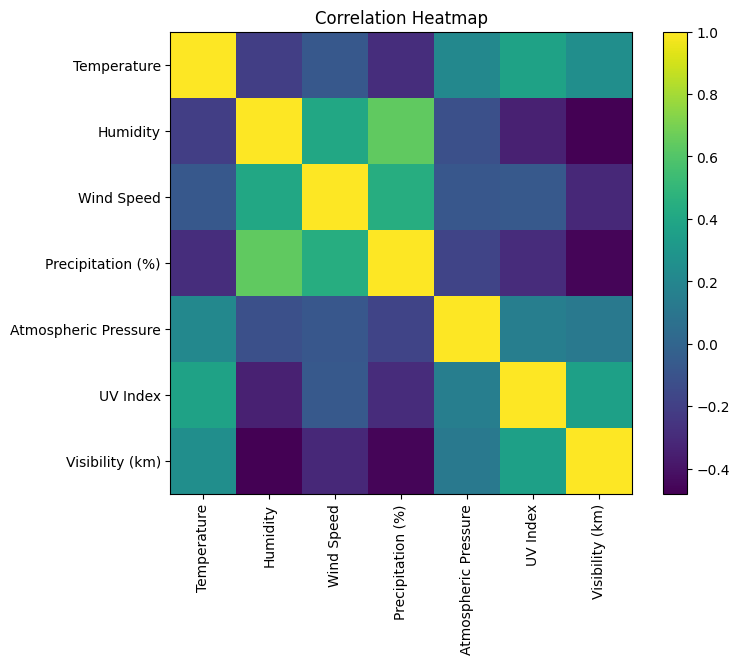

In [74]:
#correlation of the features

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="viridis")
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Heatmap")
plt.show()

In [75]:
target = "Weather Type"

numeric_cols = [
    'Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
    'Atmospheric Pressure', 'UV Index', 'Visibility (km)'
]

categorical_cols = ['Cloud Cover', 'Season', 'Location']

In [76]:

X = df.drop(columns=[target])
y = df[target]

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [78]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])
numeric_transformer

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [79]:
# Categorical preprocessing:
# - Fill missing categorical values with most frequent
# - One-hot encode text features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

categorical_transformer

,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [80]:
# Combine into one ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [81]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [82]:
num_features = numeric_cols

# Get categorical feature names after one-hot encoding
cat_features = pipeline.named_steps['preprocessor'] \
                        .named_transformers_['cat'] \
                        .named_steps['encoder'] \
                        .get_feature_names_out(categorical_cols)

# Combine all
all_features = list(num_features) + list(cat_features)

In [ ]:
# Get the trained classifier
model = pipeline.named_steps['classifier']

# Feature importances
importances = model.feature_importances_

feat_importances = pd.Series(importances, index=all_features)
feat_importances = feat_importances.sort_values(ascending=False)

print(feat_importances)


Temperature                  0.207610
Visibility (km)              0.145932
Precipitation (%)            0.135298
UV Index                     0.128674
Atmospheric Pressure         0.115285
Cloud Cover_clear            0.071800
Humidity                     0.055080
Season_Winter                0.035833
Wind Speed                   0.034193
Cloud Cover_overcast         0.020587
Location_coastal             0.012344
Cloud Cover_partly cloudy    0.009473
Cloud Cover_cloudy           0.005566
Season_Autumn                0.005548
Season_Summer                0.005504
Season_Spring                0.005015
Location_inland              0.003196
Location_mountain            0.003063
dtype: float64


In [95]:
#Evaluation of Clasification models

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [ ]:
results = {}

for name, model in models.items():
    # Create pipeline with current model
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    # Train
    clf.fit(X_train, y_train)
    
    # Predict
    y_pred = clf.predict(X_test)
    
    # Evaluation metrics
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred, average="weighted")
    }

In [99]:
results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.869318   0.870050  0.869318  0.869458
Decision Tree        0.909091   0.909280  0.909091  0.909151
Random Forest        0.915909   0.917381  0.915909  0.916266
Gradient Boosting    0.917045   0.917979  0.917045  0.917264
SVM                  0.906439   0.908387  0.906439  0.906899
KNN                  0.896212   0.898389  0.896212  0.896669


In [105]:
#Tunning the Model

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

# Parameter grid
params = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1, 0.2],
    "classifier__max_depth": [3, 4, 5]
}

from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(pipeline, params, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best F1-Score:", grid.best_score_)


c:\Users\ITG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best F1-Score: nan


In [106]:
# Correct way to create the model

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=100,
    random_state=42))
])

pipeline.fit(X_train, y_train)




,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [111]:
gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=100,
    random_state=42)

results = {}

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", gb_model)  # use your custom Gradient Boosting
])

# Train
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluation metrics
results["Gradient Boosting Custom"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1-Score": f1_score(y_test, y_pred, average="weighted")
}


In [112]:
results_df = pd.DataFrame(results).T
print(results_df)

                          Accuracy  Precision    Recall  F1-Score
Gradient Boosting Custom  0.912879   0.914035  0.912879  0.913163
